# **SARAH GAKII**

# **Facial Emotion Detection**

## **Problem Definition**

### Context and Problem Formulation

Human communication is not conveyed through words alone. Research suggests that a significant portion of emotional information is expressed through non-verbal cues. In particular, a study in communication psychology estimated that up to `55%` of emotional meaning is conveyed through facial expressions, compared to `38%` through tone of voice and only `7%` through spoken words (Mehrabian, 1971) . This highlights the critical role of visual signals in interpreting human emotions.

In many real-world interactions, accurately understanding emotional signals is essential for effective communication, decision-making, and empathy. However, consistency or accuracy in recognizing emotions, especially in high-volume or time-sensitive environments such as customer service, healthcare, or security systems, may be challenging.

With the rapid advancement of Artificial Intelligence, there is increasing interest in developing systems that can interpret human emotions automatically. This area of research is commonly referred to as **Affective Computing** or **Emotion AI**, which focuses on enabling machines to recognize and respond to human emotions through signals such as facial expressions, voice tone, and body language.

Facial Emotion Recognition (FER) is a critical component of affective computing because facial expressions are one of the most direct indicators of emotional state. The global Emotion AI market reflects this growing importance and is projected to grow significantly over the decade, driven by increasing adoption across healthcare, automotive systems, and marketing and customer experience applications.

Accurate emotion recognition systems can improve human-machine interaction, making AI systems more responsive, adaptive, and human-centered. A robust FER system can enable emotion-aware applications such as improved customer-facing virtual assistants, human behavior understanding, and supportive tools for mental health and wellbeing. For example:
- In customer service, FER can improve user satisfaction by adapting responses based on detected emotions
- In healthcare, it can assist in monitoring mental health conditions such as depression or anxiety
- In education, it can help assess student engagement in real time

Building reliable emotion recognition systems therefore represents an important step toward creating emotionally intelligent AI systems capable of interacting naturally and effectively with humans.

---

### Objective
The primary objective of this project is to develop a deep learning-based computer vision model capable of automatically identifying human facial emotions from images.

Specifically, the model should be able to:

- Analyze facial images and extract meaningful visual features.
- Learn patterns associated with different facial expressions.
- Perform multi-class classification to categorize each image into one of several emotion categories.
- Achieve strong predictive performance on unseen images.

The final model should accurately classify facial expressions into the following emotion categories:

- happy
- sad
- surprise
- neutral

The ultimate goal is to propose a reliable and scalable Facial Emotion Recognition system that can support real-world applications in human-computer interaction, customer experience, and emotion-aware AI systems.

---

## Key Questions

To guide the analysis and model development process, the following key questions are considered:

1. How well can a deep learning model learn discriminative visual features from facial images to accurately distinguish between different facial emotions from images?

2. How well does the trained model generalize to unseen data in the validation and test datasets?

3. What model architecture and training strategy produce the best performance for this classification task?

4. How does model complexity affect performance?

5. Where does the model make mistakes, and which emotions are most difficult to distinguish?

6. What insights can be derived from model predictions and errors to improve future performance?

---


## **About the dataset**

The dataset used in this project is designed for the task of Facial Emotion Recognition (FER), where the goal is to classify images of human faces into distinct emotional categories. The dataset is organized into three primary subsets: training, validation, and test sets, which are used for model training, hyperparameter tuning, and performance evaluation, respectively.

Each subset contains images grouped into four emotion classes:

**happy**: Images of individuals displaying positive facial expressions such as smiling.<br>
**sad**: Images representing negative emotional states.<br>
**surprise**: Images showing expressions of shock or astonishment.<br>
**neutral**: Images with no prominent emotional expression.<br>


## **Mounting the Drive**

In [70]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Importing the Libraries**

In [71]:
import numpy as np
import pandas as pd
import random
import os
import zipfile
from PIL import Image
import tensorflow as tf

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# Deep Learning libraries
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.layers import Flatten, Conv2D, BatchNormalization, Activation, MaxPooling2D, LeakyReLU
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tensorflow.keras import backend

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [72]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### **Let us load and unzip the data**

In [73]:
# Storing the path of the data file from the Google drive
path = '/content/drive/MyDrive/Colab Notebooks/Python for Data Science/Facial Emotion Detection Project/Facial_emotion_images.zip'

# The data is provided as a zip file so we need to extract the files from the zip file
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall()

In [74]:
folder_path = 'Facial_emotion_images/'

## **Visualizing our Classes**

### **Happy**

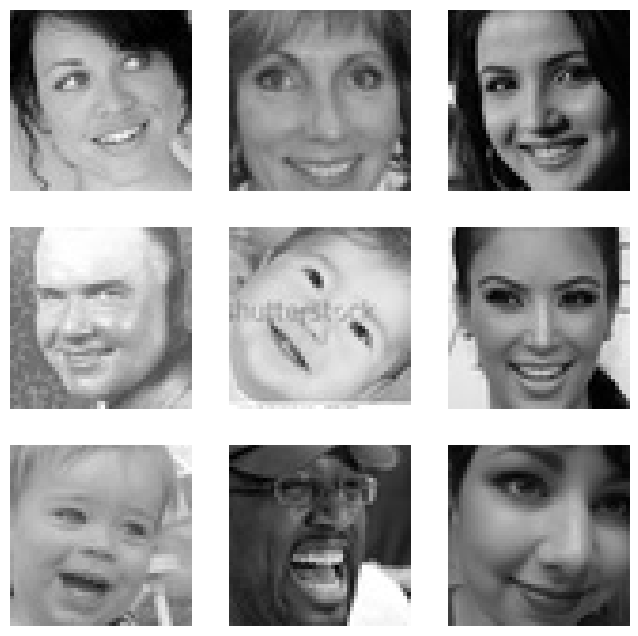

In [ ]:
plt.figure(figsize=(8,8))
for i in range(1, 10, 1):
    plt.subplot(3,3,i)

    img = load_img(folder_path + 'train/happy/' +
                   os.listdir(folder_path + 'train/happy')[i])

    plt.imshow(img)
    plt.axis('off')

plt.show()

### Observations - Happy class
- The images show a clear upward curvature of the mouth (smiling), which is the strongest visual indicator of the happy emotion.
- In several images, cheeks appear raised which is a typical facial muscle movements associated with genuine smiles.
- Faces are mostly centered and occupy most of the frame, which should help the model focus on facial features rather than background information.
- There is variation in head orientation (some faces slightly tilted), which may help the model learn more robust patterns.
- The images appear low resolution and grayscale, meaning the model will rely primarily on facial structure and expression patterns rather than color information.


The strong and consistent visual pattern of smiling may make the happy class easier for the model to learn compared to more subtle emotions.

### **Sad**

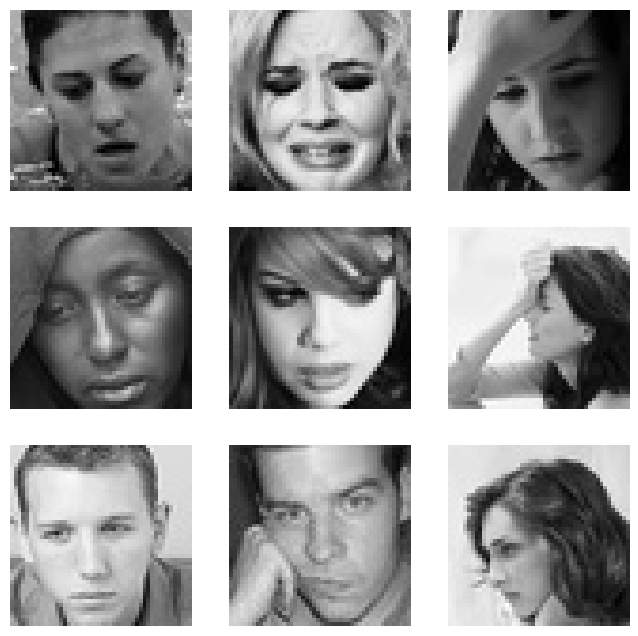

In [ ]:
plt.figure(figsize=(8,8))
for i in range(1, 10, 1):
    plt.subplot(3,3,i)

    img = load_img(folder_path + 'train/sad/' +
                   os.listdir(folder_path + 'train/sad')[i])

    plt.imshow(img)
    plt.axis('off')

plt.show()

### Observations — Sad Class

- Some faces show downward-curved lips while others show relaxed or drooping facial muscles, which are common indicators of sadness.
- Several faces display lowered eyelids or downward gaze, suggesting reduced facial energy compared to the happy class.
- There is noticeable variation in head position and viewing angle, which introduces diversity but may increase modeling complexity.
- Facial expressions in this class appear more subtle than in the happy class.


Since sad expressions can be subtle and sometimes resemble neutral expressions, the model may find it more difficult to distinguish between sad and neutral classes compared to more distinct emotions like happy or surprise.

### **Neutral**

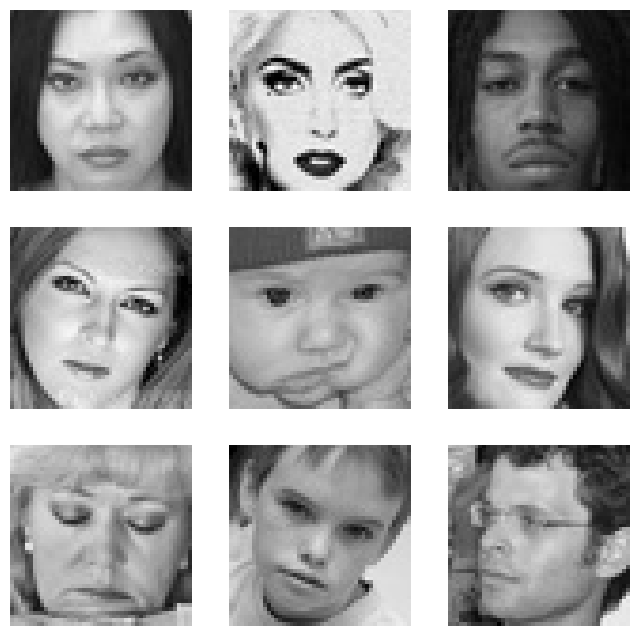

In [ ]:
plt.figure(figsize=(8,8))
for i in range(1, 10, 1):
    plt.subplot(3,3,i)

    img = load_img(folder_path + 'train/neutral/' +
                   os.listdir(folder_path + 'train/neutral')[i])

    plt.imshow(img)
    plt.axis('off')

plt.show()

### Observations — Neutral Class

- Faces generally show minimal facial muscle activation, with relaxed lips and no strong upward or downward mouth curvature.
- The eyes and eyebrows appear in a resting position, without the widening seen in surprise or the tightening seen in sadness.
- Facial expressions across images are visually similar and subtle, making the emotional signal weaker compared to classes like happy or surprise.
- Most faces are front-facing and centered, which helps emphasize the natural resting facial structure.
- As with the other classes, the images are low-resolution grayscale, meaning the model must rely primarily on facial structure rather than fine color details.


Neutral expressions may be difficult for the model to distinguish from mildly sad, since the facial features exhibit very limited emotional intensity.

### **Surprised**

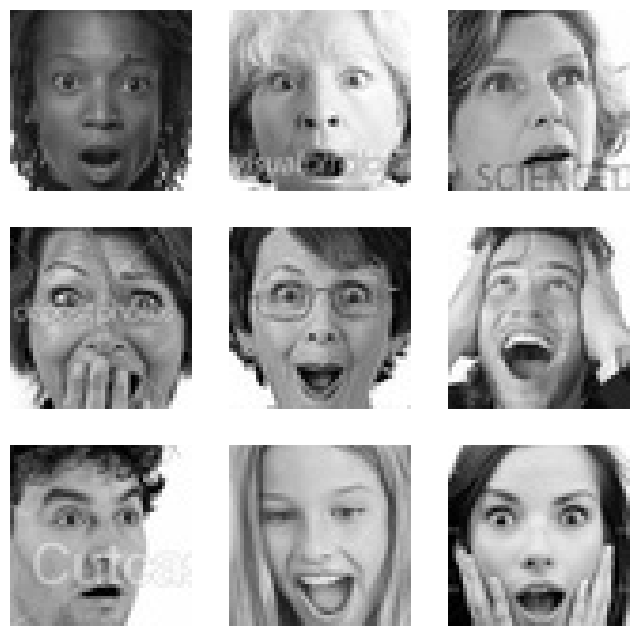

In [ ]:
plt.figure(figsize=(8,8))
for i in range(1, 10, 1):
    plt.subplot(3,3,i)

    img = load_img(folder_path + 'train/surprise/' +
                   os.listdir(folder_path + 'train/surprise')[i])

    plt.imshow(img)
    plt.axis('off')

plt.show()

### Observations — Surprise Class

- Most images show wide-open eyes and raised eyebrows, which are strong facial indicators of surprise.
- Many faces display a widely opened mouth, another common feature associated with surprised expressions.
- Compared to other classes, the facial expressions here appear more exaggerated and visually distinctive.
- Some images include hands touching the face or covering the mouth, which may introduce additional visual variation.
- There is noticeable variation in facial orientation, which may help the model learn more robust features.


Since the facial features associated with surprise are very pronounced, the model may find it easier to distinguish this class from others, especially from neutral or sad expressions.

## **Checking Distribution of Classes**

Before training a model, it is important to examine how the images are distributed across the different emotion classes. Class distribution helps us understand whether the dataset is balanced or if some classes are overrepresented or underrepresented.

A balanced dataset ensures that the model receives roughly equal exposure to each emotion category during training. If certain classes contain significantly more samples than others, the model may become biased toward predicting the majority class.

In this step, we count the number of images available for each emotion category in the dataset. This helps us:

- Understand the relative representation of each emotion
- Identify potential class imbalance
- Determine whether techniques such as class weighting or data augmentation might be needed during model training

In [ ]:
happy_count = len(os.listdir(folder_path + 'train/happy/'))
sad_count = len(os.listdir(folder_path + 'train/sad/'))
neutral_count = len(os.listdir(folder_path + 'train/neutral/'))
surprise_count = len(os.listdir(folder_path + 'train/surprise/'))

happy_count, sad_count, neutral_count, surprise_count

(3976, 3982, 3978, 3173)

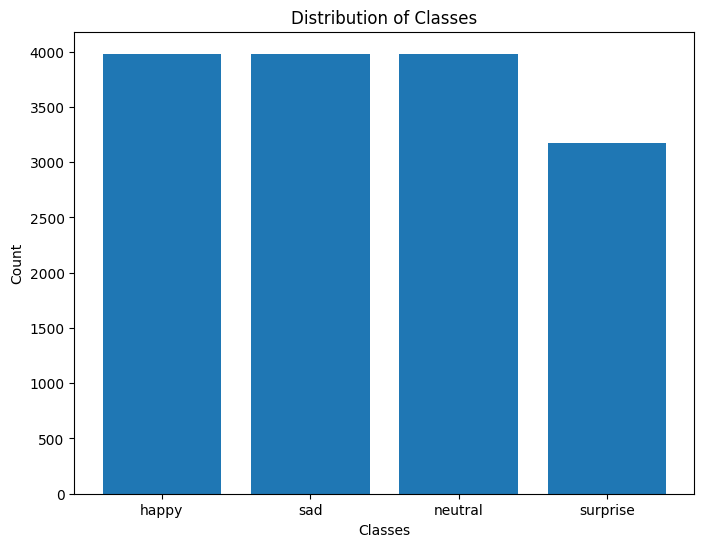

In [ ]:
plt.figure(figsize=(8,6))
plt.bar(['happy', 'sad', 'neutral', 'surprise'], [happy_count, sad_count, neutral_count, surprise_count])
plt.title('Distribution of Classes')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.show()

- The dataset is largely balanced across three classes: happy (`3976`), sad (`3982`), and neutral (`3978`).
- The surprise class contains fewer samples (`3173`) compared to the other emotions.

Overall, the dataset shows good class balance, which is beneficial for training a multi-class classifier and helps reduce bias toward any single emotion category.

However, the lower representation of the surprise class may slightly affect the model's ability to learn its patterns as effectively as the other classes.
This may lead to slightly lower recall for this class, so techniques such as data augmentation or class weighting could be helpful.

### Checking for Corrupt or Blank Images

In [ ]:
corrupt_images = []
blank_images = []

for emotion in ['happy', 'sad', 'neutral', 'surprise']:

    path = folder_path + 'train/' + emotion + '/'

    for img_name in os.listdir(path):

        img_path = path + img_name

        try:
            img = Image.open(img_path)
            img_array = np.array(img)

            # Check for blank image (all pixels identical)
            if img_array.std() == 0:
                blank_images.append(img_path)

        except:
            corrupt_images.append(img_path)

print("Number of corrupt images:", len(corrupt_images))
print("Number of blank images:", len(blank_images))

Number of corrupt images: 0
Number of blank images: 2


- No corrupt images were found in the dataset, indicating that all image files can be successfully loaded and processed.
- `2` blank images were detected, meaning these images contain no meaningful visual information, hence no useful signal for learning facial expressions and may introduce noise during model training if included.
- However, given that the dataset contains over `15,000` images, the presence of only `2` blank images is negligible and unlikely to significantly impact model performance.


### Image Properties

In [ ]:
shapes = []
pixel_values = []

for emotion in ['happy','sad','neutral','surprise']:

    path = folder_path + 'train/' + emotion + '/'

    for img_name in os.listdir(path):

        img = Image.open(path + img_name)
        img_array = np.array(img)
        shapes.append(img_array.shape)

        pixel_values.append(img_array.min())
        pixel_values.append(img_array.max())

print('Unique Image shapes: ', pd.Series(shapes).value_counts());
print('-----------------------------------------------')
print("Minimum pixel value:", min(pixel_values))
print("Maximum pixel value:", max(pixel_values))

Unique Image shapes:  (48, 48)    15109
Name: count, dtype: int64
-----------------------------------------------
Minimum pixel value: 0
Maximum pixel value: 255


- All images in the training dataset have the same spatial dimensions of `48 × 48` pixels, indicating that the dataset is already standardized in size.
- The absence of varying image dimensions simplifies preprocessing, since no additional resizing is required before model training.
- All the images are grayscale, which reduces computational complexity and memory usage.
- Pixel values range from `0` to `255`.


Since the images are small, deeper models may not be necessary. A moderately sized CNN architecture may be sufficient to capture the relevant facial expression patterns.

Also, since the pixel values span the full grayscale range (`0–255`), it will be beneficial to normalize pixel intensities during preprocessing so that the model trains on a stable numerical scale.

---
---

## **Creating our Data Loaders**

To efficiently feed images into the neural network, we create data generators. These generators load images directly from the dataset directories and performs real-time data augmentation to improve model generalization.

The generators apply several transformations including horizontal flipping, brightness adjustments, and shear transformations. These augmentations help the model become more robust to variations in facial orientation, lighting conditions, and minor geometric distortions.

Pixel values are also normalized by scaling them to the range `[0,1]`. Images are loaded in grayscale format since they are originally single-channel facial images. The generators return batches of images and corresponding categorical labels.

In [ ]:
# Create the test generator
train_datagen = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range = 0.3)

train_set = train_datagen.flow_from_directory(folder_path + "train/",
                                              target_size = (48, 48),
                                              color_mode = "grayscale",
                                              batch_size = 32,
                                              class_mode = 'categorical',
                                              shuffle = True,
                                              seed=SEED)

# Create the validation generator
validation_datagen = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range = 0.3)

validation_set = validation_datagen.flow_from_directory(folder_path + "validation/",
                                              target_size = (48, 48),
                                              color_mode = "grayscale",
                                              batch_size = 32,
                                              class_mode = 'categorical',
                                              shuffle = True,
                                              seed=SEED)

# Create the test generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow_from_directory(folder_path + "test/",
                                              target_size = (48, 48),
                                              color_mode = "grayscale",
                                              batch_size = 32,
                                              class_mode = 'categorical',
                                              shuffle = False,
                                             seed=SEED)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


- The training generator successfully detected `15,109` images across `4` emotion classes, confirming that the full training dataset has been correctly loaded.
- The validation generator contains `4,977` images, which will be used to monitor model performance during training and help detect overfitting.
- The test generator contains `128` images, which will be reserved for final model evaluation on unseen data.
  

In [ ]:
train_set.class_indices

{'happy': 0, 'neutral': 1, 'sad': 2, 'surprise': 3}

The class index mapping created automatically by the generator is:
   - happy: 0
   - neutral: 1
   - sad: 2
   - surprise: 3

This mapping indicates how the emotion labels are encoded internally during training.

## **Model Building**

This problem involves image data, where the input consists of pixel grids representing facial expressions. For such tasks, Convolutional Neural Networks (CNNs) are the most appropriate model architecture.

A traditional Artificial Neural Network (ANN) treats inputs as a flat vector. Thus, each `48×48` image would first be flattened into a vector of `2,304` pixels. This approach ignores the spatial relationships between neighboring pixels, which are critical for recognizing facial patterns such as eyes, eyebrows, and mouth shapes.

CNNs, on the other hand, use convolutional filters to detect local visual patterns such as edges, textures, and facial structures. As the network deepens, these features combine to form higher-level representations that help identify complex patterns like emotional expressions.

Key advantages of CNNs over ANNs include:

- **Preservation of spatial structure:** CNNs analyze local pixel neighborhoods, allowing them to capture meaningful visual features in images.
- **Automatic feature extraction:** CNNs learn hierarchical features without manual feature engineering.
- **Parameter efficiency:** Convolutional layers share weights across the image, drastically reducing the number of parameters compared to fully connected networks.
- **Translation robustness:** CNNs can recognize patterns even if facial features appear in slightly different positions.


These advantages are highly relevant for facial emotion recognition, where identifying subtle spatial relationships between facial components is essential.

---

### **Creating the Base Neural Network**

The base model is implemented using a Sequential Convolutional Neural Network (CNN) designed to learn hierarchical visual features from facial images. The network processes grayscale images and outputs probabilities across four emotion classes.

The architecture consists of `3` convolutional blocks followed by fully connected layers, allowing the model to progressively extract and combine visual features.

Each convolutional block performs feature extraction and includes four components:

- Conv2D layer (`64` filters, `2×2` kernel, ReLU activation):  
  Applies learnable filters across the image to detect local patterns.
- Batch Normalization:  
  Normalizes activations within the network, improving training stability and accelerating convergence.
- MaxPooling (`2×2`):  
  Reduces spatial dimensions while retaining the most important features, helping the network focus on dominant patterns.
- Dropout:  
  Randomly disables a fraction of neurons during training to reduce overfitting and improve model generalization.

Using three such blocks allows the network to learn complex facial features, from simple edges to higher-level structures related to facial expressions.

After the convolutional feature extraction, the Flatten layer converts the 2D feature maps into a 1D vector so that they can be processed by fully connected layers.


- Dense layer (512 neurons, ReLU activation):
  Combines extracted features to learn complex relationships between facial patterns and emotional categories.

- Dropout (0.4):  
  Adds additional regularization to prevent overfitting in the dense layer.

The final Dense layer uses softmax activation with `4` neurons, producing a probability distribution across the four emotion classes.
The predicted class corresponds to the emotion with the highest probability score.

In [ ]:
backend.clear_session()

In [ ]:
input_shape = (48, 48, 1) # since color_mode="grayscale"
num_classes = 4

# Initialize a Sequential Model
model_1 = Sequential()

# First Convolutional block
model_1.add(Conv2D(64, kernel_size=(2, 2), activation='relu', padding='same', input_shape=input_shape))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(0.2))

# Second Convolutional block
model_1.add(Conv2D(64, kernel_size=(2, 2), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(0.25))

# Third Convolutional block
model_1.add(Conv2D(64, kernel_size=(2, 2), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(0.25))

# Flatten layer
model_1.add(Flatten())

# Dense layer
model_1.add(Dense(512, activation='relu'))
model_1.add(Dropout(0.4))

# Output layer
model_1.add(Dense(num_classes, activation='softmax'))

model_1.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,216,196 (4.64 MB)

 Trainable params: 1,215,812 (4.64 MB)

 Non-trainable params: 384 (1.50 KB)

### **Compiling and Training the Model**

In [ ]:
# --- Callbacks ---

# Early stopping
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 4,
    min_delta = 0,
    verbose = 1,
    restore_best_weights = True
    )

# Reduce learning rate
reduce_lr = ReduceLROnPlateau(
    monitor = "val_loss",
    patience = 3,
    factor = 0.5,
    min_lr = 1e-6,
    verbose = 1
    )

# Model checkpoint
checkpoint = ModelCheckpoint(
    filepath = "best_model_1.keras",
    monitor = "val_accuracy",
    save_best_only = True,
    mode = 'max',
    verbose = 1
    )

epochs = 20

In [ ]:
model_1.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
    )

In [ ]:
history_1 = model_1.fit(
    train_set,
    validation_data = validation_set,
    epochs = epochs,
    callbacks = [early_stop, reduce_lr, checkpoint]
    )

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3032 - loss: 1.9883
Epoch 1: val_accuracy improved from -inf to 0.41772, saving model to best_model_1.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.3033 - loss: 1.9873 - val_accuracy: 0.4177 - val_loss: 1.7030 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4409 - loss: 1.2107
Epoch 2: val_accuracy improved from 0.41772 to 0.51778, saving model to best_model_1.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.4409 - loss: 1.2106 - val_accuracy: 0.5178 - val_loss: 1.0763 - learning_rate: 0.0010
Epoch 3/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4982 - loss: 1.1241
Epoch 3: val_accuracy improved from 0.51778 to 0.53928, saving model to best_model_1.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.4982 - loss: 1.1241 - val_accuracy: 0.5393 - val_loss: 1.0758 - learning_rate: 0.0010
Epoch 4/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/ste

The best validation accuracy achieved during training was approximately `68%`, indicating that the model learned useful representations for distinguishing between the four facial emotions.

The training accuracy was about `66%`, which is very close to the validation accuracy. This indicates good generalization, and suggests that the model did not show strong overfitting.

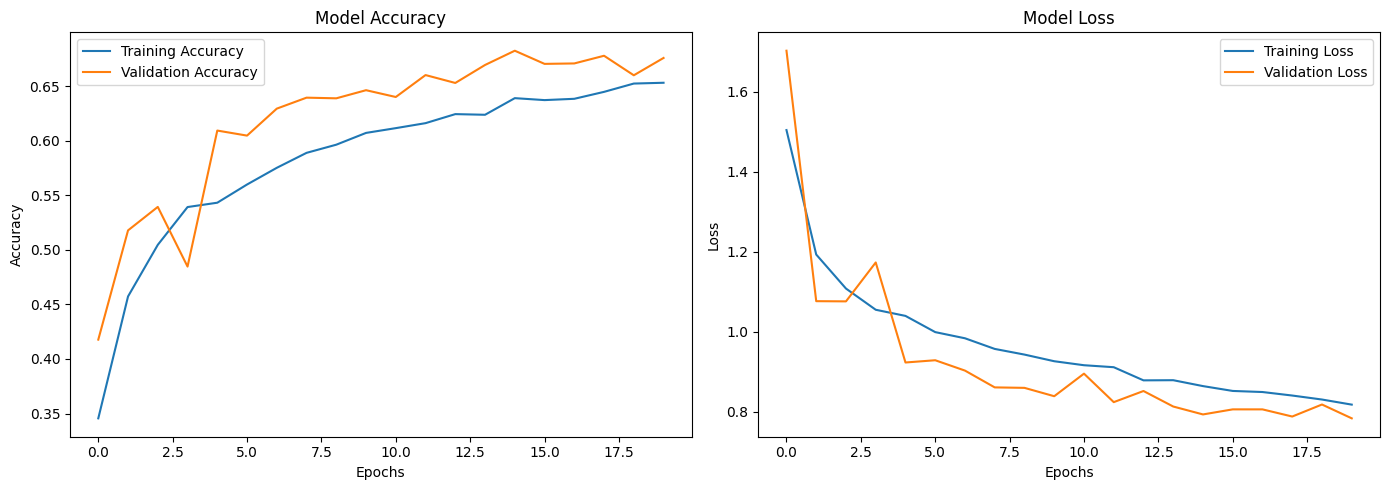

In [ ]:
plt.figure(figsize=(14,5))

# --- Accuracy Plot ---
plt.subplot(1,2,1)
plt.plot(history_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# --- Loss Plot ---
plt.subplot(1,2,2)
plt.plot(history_1.history['loss'], label='Training Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Both training and validation accuracy increase steadily throughout training and remain close to each other. The absence of a large gap between the curves suggests that the model generalizes reasonably well and does not exhibit significant overfitting.

Similarly, training and validation loss decrease consistently and stabilize toward the later epochs, indicating stable convergence during optimization.


### **Evaluating the Model on the Test Set**

In [ ]:
# Load best saved model
model_1 = load_model("best_model_1.keras")

# Reset generator
test_set.reset()

#Evaluate the best model on the test set
test_loss, test_accuracy = model_1.evaluate(test_set, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.7365 - loss: 0.6210
Test Loss: 0.664936363697052
Test Accuracy: 0.71875


After training, the model was evaluated on the unseen test dataset to assess its generalization performance.

- Test Loss: `~0.665`  
- Test Accuracy: `~71.9%`

These results indicate that the model is able to correctly classify facial emotions in approximately `72%` of unseen images. The test accuracy is slightly higher than the training accuracy (`~66%`) and comparable to the validation accuracy (`~68%`), suggesting that the model generalizes reasonably well and does not exhibit significant overfitting.

The consistency between training, validation, and test performance indicates that the model has learned meaningful facial expression patterns rather than memorizing the training data.

While the model demonstrates stable generalization, the overall accuracy suggests that there is still room for improvement. Facial emotion recognition is inherently challenging due to subtle expression differences, and further improvements may be achieved through architectural tuning, additional convolutional layers, or transfer learning approaches.

### Plotting Confusion Matrix

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step 
['happy', 'neutral', 'sad', 'surprise']


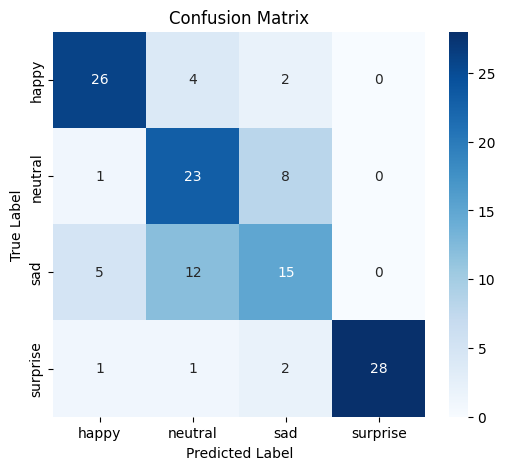

In [ ]:
# Generate Predictions
predictions = model_1.predict(test_set)

# Convert probabilities to predicted class labels
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = test_set.classes

# Class labels
class_labels = list(test_set.class_indices.keys())
print(class_labels)

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix provides a detailed view of how the model performs across the four emotion classes by comparing the true labels with the predicted labels.

**Happy**
- The model performs relatively well on happy expressions, likely due to the distinct visual cue of smiling.

**Neutral**
- Most common error: classified as sad.
- Neutral expressions appear to share subtle visual similarities with sad expressions, making them harder to distinguish.

**Sad**
- Frequently misclassified as neutral and happy.
- This indicates that sad expressions are more ambiguous, especially when facial cues are mild.

**Surprise**
- Very few misclassifications.
- This is expected because surprised expressions typically involve distinct features such as wide-open eyes and mouth**, making them easier for the model to detect.

Overall, the confusion matrix aligns with expectations for facial emotion recognition tasks, where subtle emotional expressions are harder to classify than exaggerated ones.

### Classification report analysis

In [ ]:
# Classification report
print(classification_report(true_classes,
                            predicted_classes,
                            target_names=class_labels))

              precision    recall  f1-score   support

       happy       0.79      0.81      0.80        32
     neutral       0.57      0.72      0.64        32
         sad       0.56      0.47      0.51        32
    surprise       1.00      0.88      0.93        32

    accuracy                           0.72       128
   macro avg       0.73      0.72      0.72       128
weighted avg       0.73      0.72      0.72       128



The model performs well on the happy class. Both precision (`0.79`) and recall (`0.81`) are relatively high, indicating that the model correctly identifies most happy expressions while making relatively few incorrect predictions.

On the neutral class, the recall (`0.72`) is relatively strong, meaning the model successfully detects many neutral expressions. However, the lower precision(`0.57`) suggests that some images predicted as neutral actually belong to other classes, particularly sad.

The sad class is the most challenging class for the model. The low recall (`0.47`) indicates that many sad images are misclassified, often as neutral. This aligns with the confusion matrix, where sad and neutral expressions were frequently confused due to their subtle visual differences.

The model performs exceptionally well on the surprise class, with a precision of `1.00` and recall of `0.88`.

Overall Performance

- Overall accuracy: 72%
- Macro average F1-score: 0.72
- Weighted average F1-score: 0.72

The similar macro and weighted averages indicate that performance across classes is relatively balanced.

However, the model clearly performs better on expressive emotions (happy, surprise) than on subtle emotions (neutral, sad).


  ------------------------------------------------------------------------

   ------------------------------------------------------------------------

## **Creating the second Convolutional Neural Network**

To improve performance, we build a second CNN with a larger architecture than the base CNN model.

The goal of this larger architecture is to improve feature extraction and achieve stronger classification performance, particularly for the more subtle classes.

In [ ]:
backend.clear_session()

In [ ]:
input_shape = (48, 48, 1)
num_classes = 4

model_2 = Sequential()

# First block (activation=None)
model_2.add(Conv2D(64, kernel_size=(3, 3), padding='same', input_shape=input_shape))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(negative_slope=0.1))
model_2.add(Conv2D(64, (3, 3), padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(negative_slope=0.1))
model_2.add(MaxPooling2D(pool_size=(2, 2)))
model_2.add(Dropout(0.25))

# Second block
model_2.add(Conv2D(128, (3, 3), padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(negative_slope=0.1))
model_2.add(Conv2D(128, (3, 3), padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(negative_slope=0.1))
model_2.add(MaxPooling2D(pool_size=(2, 2)))
model_2.add(Dropout(0.30))

# Third block
model_2.add(Conv2D(256, (3, 3), padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(negative_slope=0.1))
model_2.add(Conv2D(256, (3, 3), padding='same'))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(negative_slope=0.1))
model_2.add(MaxPooling2D(pool_size=(2, 2)))
model_2.add(Dropout(0.35))

# Classification head
model_2.add(GlobalAveragePooling2D())

# Dense layer
model_2.add(Dense(256))
model_2.add(BatchNormalization())
model_2.add(LeakyReLU(negative_slope=0.1))
model_2.add(Dropout(0.40))

# Output layer
model_2.add(Dense(num_classes, activation='softmax'))

model_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 12, 12, 256)    │             

 Total params: 1,215,684 (4.64 MB)

 Trainable params: 1,213,380 (4.63 MB)

 Non-trainable params: 2,304 (9.00 KB)

### **Compiling and Training the Model**

In [ ]:
# --- Callbacks ---

# Early stopping
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 4,
    min_delta = 0,
    verbose = 1,
    restore_best_weights = True
    )

# Reduce learning rate
reduce_lr = ReduceLROnPlateau(
    monitor = "val_loss",
    patience = 3,
    factor = 0.5,
    min_lr = 1e-6,
    verbose = 1
    )

# Model checkpoint
checkpoint = ModelCheckpoint(
    filepath = "best_model_2.keras",
    monitor = "val_accuracy",
    save_best_only = True,
    mode = 'max',
    verbose = 1
    )

epochs = 30

In [ ]:
model_2.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
    )

In [ ]:
history_2 = model_2.fit(
    train_set,
    validation_data = validation_set,
    epochs = epochs,
    callbacks = [early_stop, reduce_lr, checkpoint]
    )

Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2657 - loss: 1.6385
Epoch 1: val_accuracy improved from -inf to 0.35122, saving model to best_model_2.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 43s 64ms/step - accuracy: 0.2657 - loss: 1.6383 - val_accuracy: 0.3512 - val_loss: 1.3498 - learning_rate: 0.0010
Epoch 2/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2679 - loss: 1.4544
Epoch 2: val_accuracy did not improve from 0.35122
473/473 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.2679 - loss: 1.4543 - val_accuracy: 0.2118 - val_loss: 1.5548 - learning_rate: 0.0010
Epoch 3/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2985 - loss: 1.3894
Epoch 3: val_accuracy did not improve from 0.35122
473/473 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.2985 - loss: 1.3894 - val_accuracy: 0.2548 - val_loss: 1.3915 - learning_rate: 0.0010
Epoch 4/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3543 - loss: 1.3160
Epoch 4: val_accuracy improved fr

The second CNN achieved substantially better performance than the first model.
- Training accuracy increased to `~78%` compared to `~66%` training accuracy in the base model.
- Validation accuracy reached `~76%` from `~68%` validation accuracy in the base model.


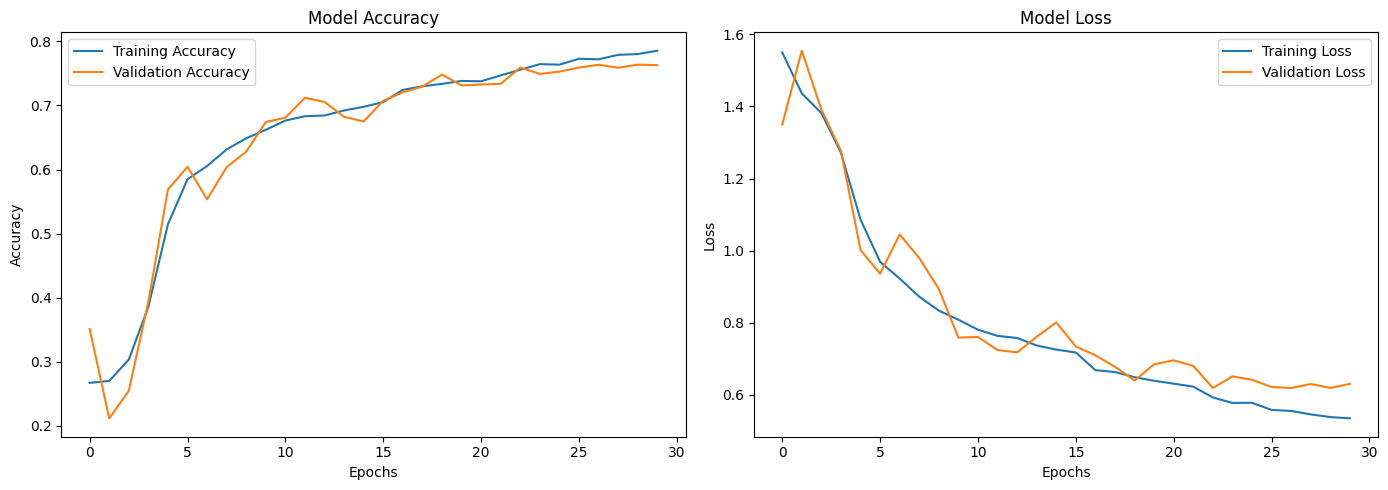

In [ ]:
plt.figure(figsize=(14,5))

# --- Accuracy Plot ---
plt.subplot(1,2,1)
plt.plot(history_2.history['accuracy'], label='Training Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# --- Loss Plot ---
plt.subplot(1,2,2)
plt.plot(history_2.history['loss'], label='Training Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

The training and validation curves show stable learning behavior throughout the training process.

- The training and validation accuracy curves remain closely aligned, suggesting that the model generalizes well and does not exhibit strong overfitting.


### **Evaluating the Model on the Test Set**

In [ ]:
# Load best saved model
model_2 = load_model("best_model_2.keras")

#Evaluate the best model on the test set
test_loss, test_accuracy = model_2.evaluate(test_set, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8531 - loss: 0.4210
Test Loss: 0.4541051387786865
Test Accuracy: 0.8359375


The second CNN model was evaluated on the unseen test dataset to assess its final generalization performance.

- Test Loss: `0.454`  
- Test Accuracy: `83.6%`

This represents a substantial improvement over the base CNN model, which achieved approximately `72%` test accuracy. The improved performance indicates that the larger architecture is more effective at learning discriminative facial features for emotion recognition.


The test accuracy (`~83.6%`) is slightly higher than the validation accuracy (`~76%`), which can occur due to the relatively small test sample size.


### Confusion Matrix

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
['happy', 'neutral', 'sad', 'surprise']


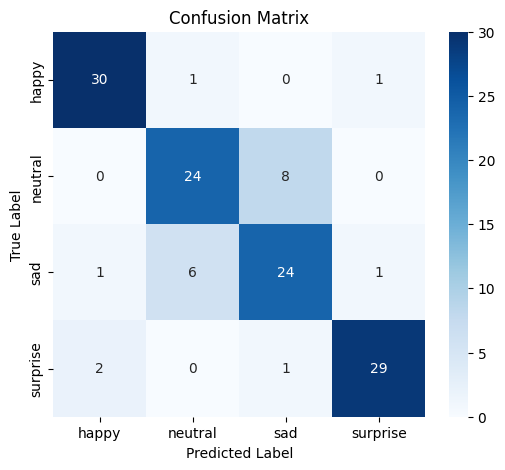

In [ ]:
# Generate Predictions
predictions = model_2.predict(test_set)

# Convert probabilities to predicted class labels
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = test_set.classes

# Class labels
class_labels = list(test_set.class_indices.keys())
print(class_labels)

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows how well the second CNN distinguishes between the four emotion classes on the test dataset.

**Happy**
- Very few misclassifications.
- The model identifies happy expressions reliably, likely due to distinctive smiling features.

**Neutral**
- Most common error: predicted as sad.
- Neutral expressions remain challenging because they share subtle visual similarities with sad expressions.

**Sad**
- Misclassified mainly as neutral.
- The confusion between sad and neutral persists, though it is reduced compared to the first model.

**Surprise**
- Only minor misclassifications.
- Surprise remains an easy class to detect due to its distinctive facial features.

Overall, the confusion matrix confirms that the deeper architecture and improved feature extraction in the second model lead to better discrimination between emotional expressions.

### Classification report analysis

In [ ]:
# Classification report
print(classification_report(true_classes,
                            predicted_classes,
                            target_names=class_labels))

              precision    recall  f1-score   support

       happy       0.91      0.94      0.92        32
     neutral       0.77      0.75      0.76        32
         sad       0.73      0.75      0.74        32
    surprise       0.94      0.91      0.92        32

    accuracy                           0.84       128
   macro avg       0.84      0.84      0.84       128
weighted avg       0.84      0.84      0.84       128



The classification report provides detailed performance metrics for each emotion class.

The model performs very well on happy expressions, correctly identifying most instances while making very few incorrect predictions.

Performance on the neutral class is moderate. Some neutral expressions are misclassified as sad, reflecting the subtle differences between these emotional states.

The model shows improved performance on sad expressions compared to the first CNN. However, some confusion with neutral expressions remains due to their similar facial characteristics.

The model achieves a very good performance on surprise expressions, which typically contain strong visual cues.


The macro and weighted averages are nearly identical, indicating that the model performs consistently across classes.


Compared to the first CNN model, the second architecture significantly improves classification performance across all emotion categories.
- The deeper convolutional layers and improved archictural strategy enable the model to learn richer facial representations, leading to stronger overall performance while maintaining balanced accuracy across classes.

---
---

## **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. These architectures will require 3 input channels different from the earlier ones that worked on 'grayscale' images. Therefore, we need to create new DataLoaders.

### **Creating our Data Loaders for Transfer Learning Architectures**

In this section, we are creating data loaders that we will use as inputs to our Neural Network.

In [100]:
def build_generators(preprocess_function, img_size=128, batch_size=32):

  # Create the test generator
  train_datagen = ImageDataGenerator(preprocessing_function = preprocess_input,
                                    horizontal_flip = True,
                                    rotation_range=10,
                                    width_shift_range=0.05,
                                    height_shift_range=0.05,
                                    zoom_range=0.05
                                    )

  train_set = train_datagen.flow_from_directory(folder_path + "train/",
                                                target_size = (img_size, img_size),
                                                color_mode = "rgb",
                                                batch_size = batch_size,
                                                class_mode = 'categorical',
                                                classes = ['happy', 'neutral', 'sad', 'surprise'],
                                                shuffle = True,
                                                seed=SEED)

  # Create the validation generator
  validation_datagen = ImageDataGenerator(preprocessing_function = preprocess_input,
                                          horizontal_flip = True,
                                          rotation_range=10,
                                          width_shift_range=0.05,
                                          height_shift_range=0.05,
                                          zoom_range=0.05)

  validation_set = validation_datagen.flow_from_directory(folder_path + "validation/",
                                                target_size = (img_size, img_size),
                                                color_mode = "rgb",
                                                batch_size = batch_size,
                                                class_mode = 'categorical',
                                                classes = ['happy', 'neutral', 'sad', 'surprise'],
                                                shuffle = True,
                                                seed=SEED)

  # Create the test generator
  test_datagen = ImageDataGenerator(preprocessing_function = preprocess_input)

  test_set = test_datagen.flow_from_directory(folder_path + "test/",
                                                target_size = (img_size, img_size),
                                                color_mode = "rgb",
                                                batch_size = batch_size,
                                                class_mode = 'categorical',
                                                classes = ['happy', 'neutral', 'sad', 'surprise'],
                                                shuffle = False,
                                              seed=SEED)


  return train_set, validation_set, test_set

- The new data loaders were created successfully for transfer learning models.

## **VGG16 Model**

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications import VGG16

# Data loaders
train_set, validation_set, test_set = build_generators(preprocess_input)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


### **Importing the VGG16 Architecture**

In [ ]:
#backend.clear_session()

We use VGG16 as a transfer learning feature extractor, thus remove the original fully connected classifier used for ImageNet classification. This allows the convolutional base to extract meaningful visual features from facial images, which are then passed to a custom classification head designed specifically for the four emotion classes in the dataset.

The model is initialized with pretrained ImageNet weights, allowing it to leverage visual representations learned from millions of images.

In [ ]:
img_size=128

# Loading the pretrained VGG16 backbone
vgg = VGG16(include_top = False, # remove the original classifier
            weights = 'imagenet', # use pretrained ImageNet weights
            input_shape = (img_size, img_size, 3))
vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### **Model Building**


The VGG model is truncated at the `block5_pool` layer. At this stage, the network has already extracted high-level spatial features from the input images.

To allow limited adaptation to the facial emotion recognition task, only the deepest layers of the VGG architecture are unfrozen while all earlier layers remain frozen. This strategy preserves the general visual features learned from ImageNet while enabling the model to refine higher-level representations relevant to facial expressions.


Following the convolutional base, a classification head is then added.


In [ ]:
num_classes = 4

for layer in vgg.layers:
    if layer.name in ['block5_conv3', 'block5_pool']:
        layer.trainable = True
    else:
        layer.trainable = False

model_vgg = Sequential()

# Pretrained VGG16 base
model_vgg.add(vgg)
model_vgg.add(GlobalAveragePooling2D())


# Classification head
model_vgg.add(Dense(256, kernel_regularizer=l2(2e-4)))
model_vgg.add(BatchNormalization())
model_vgg.add(LeakyReLU(negative_slope=0.1))
model_vgg.add(Dropout(0.6))

# Output layer
model_vgg.add(Dense(num_classes, activation='softmax'))

model_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,068 (56.64 MB)

 Trainable params: 2,492,676 (9.51 MB)

 Non-trainable params: 12,355,392 (47.13 MB)

### **Compiling and Training the VGG16 Model**

In [ ]:
# --- Callbacks ---

# Early stopping
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    verbose = 1,
    restore_best_weights = True
    )

# Reduce learning rate
reduce_lr = ReduceLROnPlateau(
    monitor = "val_loss",
    patience = 2,
    factor = 0.5,
    min_lr = 1e-8,
    verbose = 1
    )

# Model checkpoint
checkpoint = ModelCheckpoint(
    filepath = "best_vgg_model.keras",
    monitor = "val_accuracy",
    save_best_only = True,
    mode = 'max',
    verbose = 1
    )

epochs = 40

In [ ]:
model_vgg.compile(
    optimizer = Adam(learning_rate = 2e-5),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
    )

In [ ]:
history_vgg = model_vgg.fit(
    train_set,
    validation_data = validation_set,
    epochs = epochs,
    callbacks = [early_stop, reduce_lr, checkpoint]
)

Epoch 1/40
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.3537 - loss: 1.7935
Epoch 1: val_accuracy improved from None to 0.61583, saving model to best_vgg_model.keras

Epoch 1: finished saving model to best_vgg_model.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 96s 180ms/step - accuracy: 0.4181 - loss: 1.6135 - val_accuracy: 0.6158 - val_loss: 1.0318 - learning_rate: 2.0000e-05
Epoch 2/40
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.5116 - loss: 1.3475
Epoch 2: val_accuracy improved from 0.61583 to 0.65923, saving model to best_vgg_model.keras

Epoch 2: finished saving model to best_vgg_model.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 74s 157ms/step - accuracy: 0.5317 - loss: 1.3071 - val_accuracy: 0.6592 - val_loss: 0.9289 - learning_rate: 2.0000e-05
Epoch 3/40
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5695 - loss: 1.2088
Epoch 3: val_accuracy improved from 0.65923 to 0.68274, saving model to best_vgg_model.keras

Epoch 3: finished saving model to best_vgg_model.ke

The VGG16-based transfer learning model shows strong and stable learning behavior. Validation accuracy improves steadily to a best value of approximately `74.9%`, indicating that the pretrained convolutional features are effective for facial emotion recognition.

Compared with the first custom CNN, the VGG16 model performs substantially better. However, its best validation accuracy (`~74.9%`) is still slightly below the second custom CNN model (`~76.4%`).

This suggests that transfer learning with VGG16 is effective, but in this case the larger custom CNN is at least as competitive, likely because the facial emotion dataset is relatively specialized and low-resolution.


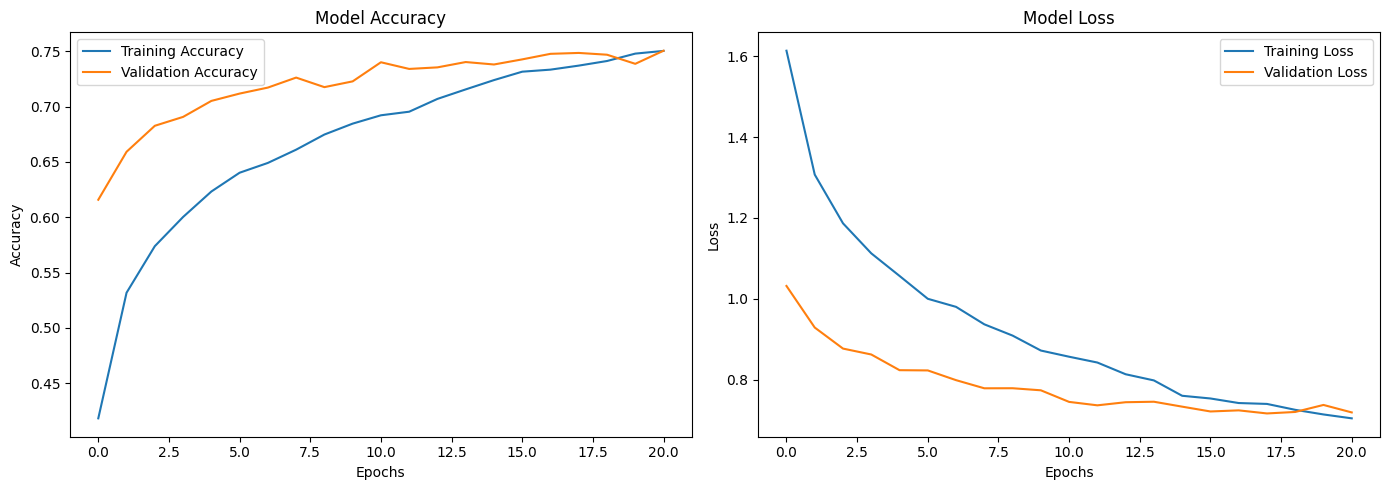

In [ ]:
plt.figure(figsize=(14,5))

# --- Accuracy Plot ---
plt.subplot(1,2,1)
plt.plot(history_vgg.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# --- Loss Plot ---
plt.subplot(1,2,2)
plt.plot(history_vgg.history['loss'], label='Training Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


- Training and validation accuracy increase consistently and are relatively close, suggesting good generalization and no severe overfitting.
- Validation loss decreases steadily indicating that the model is learning meaningful facial representations.

### **Evaluating the VGG16 model**

In [ ]:
# Load best saved model
model_vgg = load_model("best_vgg_model.keras")

#Evaluate the best model on the test set
test_loss, test_accuracy = model_vgg.evaluate(test_set, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7266 - loss: 0.7280
Test Loss: 0.7279930114746094
Test Accuracy: 0.7265625


The VGG16 transfer learning model was evaluated on the unseen test dataset to measure its final generalization performance:

- Test Loss: `0.728`  
- Test Accuracy: `72.7%`

While the VGG16 model performs better than the first custom CNN, it does not outperform the second custom CNN model, which achieved `83.6%` test accuracy.



### Confusion Matrix

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
['happy', 'neutral', 'sad', 'surprise']


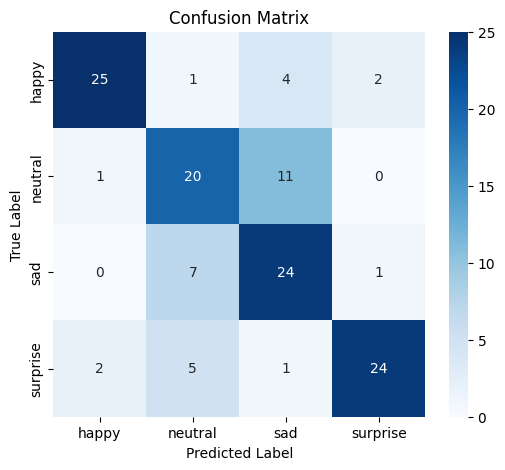

In [ ]:
# Generate Predictions
predictions = model_vgg.predict(test_set)

# Convert probabilities to predicted class labels
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = test_set.classes

# Class labels
class_labels = list(test_set.class_indices.keys())
print(class_labels)

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

- The model occasionally confuses happy with sad, likely due to subtle facial similarities in grayscale images.
- Neutral expressions continue to be confused with sad expressions.
- The model performs relatively well on sad expressions compared to neutral.
- Surprise expressions are generally distinctive but occasionally overlap with neutral likely when facial cues are less pronounced.

The primary confusion consistent with earlier models occurs between neutral and sad.
The model also shows some confusion between happy and sad, which may arise from grayscale images reducing color cues that could otherwise help distinguish expressions.


### Classification report analysis

In [ ]:
# Classification report
print(classification_report(true_classes,
                            predicted_classes,
                            target_names=class_labels))

              precision    recall  f1-score   support

       happy       0.89      0.78      0.83        32
     neutral       0.61      0.62      0.62        32
         sad       0.60      0.75      0.67        32
    surprise       0.89      0.75      0.81        32

    accuracy                           0.73       128
   macro avg       0.75      0.73      0.73       128
weighted avg       0.75      0.73      0.73       128




- The model performs reasonably well on happy and surprise, but struggles more with neutral and sad, similar to earlier models.
- Compared to Model 2, performance drops across all classes, especially in neutral and sad discrimination.
- The gap between precision and recall in some classes suggests inconsistent decision boundaries.


The macro and weighted averages are similar, indicating relatively balanced performance across classes.

Overall, the VGG16 model generalizes reasonably well but does not surpass the performance of the deeper custom CNN model developed earlier.



---
---

## **ResNet V2 Model**

Next we evaluate a transfer learning architecture based on ResNetV2. Compared with VGG16, ResNetV2 uses residual connections, which allow information to flow more effectively through deeper networks and help mitigate optimization difficulties such as vanishing gradients.

In this project, ResNetV2 is used as a pretrained feature extractor, followed by a custom classification head tailored to the four facial emotion classes.

The goal is to determine whether a deeper residual architecture can provide stronger feature representations.

In [130]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input

# Data loaders
train_set, validation_set, test_set = build_generators(preprocess_input)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


In [131]:
#backend.clear_session()

In [132]:
img_size = 128

resnet = ResNet50V2(include_top = False,
                    weights = "imagenet",
                    input_shape=(img_size,img_size,3))
resnet.summary()

Model: "resnet50v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 32, 32,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 32, 32,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 34, 34,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 32, 32,    │          0 │ conv2_block1_0_c

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 23,519,360 (89.72 MB)

 Non-trainable params: 45,440 (177.50 KB)

### **Model Building**



The ResNet base network is loaded with pretrained weights and a custom classification head is added on top of the pretrained network. Only the deepest layers of ResNet are unfrozen while all earlier layers remain frozen.

The pretrained ResNet extracts general visual features, while the added dense layers learn emotion-specific patterns from the facial dataset.

In [133]:
num_classes = 4


for layer in resnet.layers:
    if layer.name.startswith("conv5_block3") or \
      layer.name in ["post_bn", "post_relu"]:
        layer.trainable = True
    else:
        layer.trainable = False


model_resnet = Sequential()

# Pretrained ResNet base
model_resnet.add(resnet)
model_resnet.add(GlobalAveragePooling2D())
model_resnet.add(Dropout(0.4))

# Classification head
model_resnet.add(Dense(128, kernel_regularizer=l2(1e-4)))
model_resnet.add(BatchNormalization())
model_resnet.add(LeakyReLU(negative_slope=0.1))
model_resnet.add(Dropout(0.5))

# Output layer
model_resnet.add(Dense(num_classes, activation='softmax'))

model_resnet.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 4, 4, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,828,100 (90.90 MB)

 Trainable params: 4,731,780 (18.05 MB)

 Non-trainable params: 19,096,320 (72.85 MB)

### **Compiling and Training the Model**

In [134]:
# --- Callbacks ---

# Early stopping
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 2,
    verbose = 1,
    restore_best_weights = True
    )

# Reduce learning rate
reduce_lr = ReduceLROnPlateau(
    monitor = "val_loss",
    patience = 2,
    factor = 0.5,
    min_lr = 1e-7,
    verbose = 1
    )

# Model checkpoint
checkpoint = ModelCheckpoint(
    filepath = "best_resnet_model.keras",
    monitor = "val_accuracy",
    save_best_only = True,
    mode = 'max',
    verbose = 1
    )

epochs = 30

In [136]:
model_resnet.compile(
    optimizer = Adam(learning_rate = 3e-5),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
    )

In [137]:
history_resnet = model_resnet.fit(
    train_set,
    validation_data=validation_set,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.3399 - loss: 1.6985
Epoch 1: val_accuracy improved from None to 0.55977, saving model to best_resnet_model.keras

Epoch 1: finished saving model to best_resnet_model.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 100s 184ms/step - accuracy: 0.3894 - loss: 1.5681 - val_accuracy: 0.5598 - val_loss: 1.1382 - learning_rate: 3.0000e-05
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.5076 - loss: 1.2958
Epoch 2: val_accuracy improved from 0.55977 to 0.63773, saving model to best_resnet_model.keras

Epoch 2: finished saving model to best_resnet_model.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accuracy: 0.5164 - loss: 1.2526 - val_accuracy: 0.6377 - val_loss: 0.9289 - learning_rate: 3.0000e-05
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.5709 - loss: 1.1154
Epoch 3: val_accuracy improved from 0.63773 to 0.66024, saving model to best_resnet_model.keras

Epoch 3: finished saving model to b

The ResNet model achieved a best validation accuracy of `74.6%`, which is competitive with VGG16 `(74.9%`) but still slightly below the custom CNN Model 2 (`76.4%` validation accuracy).


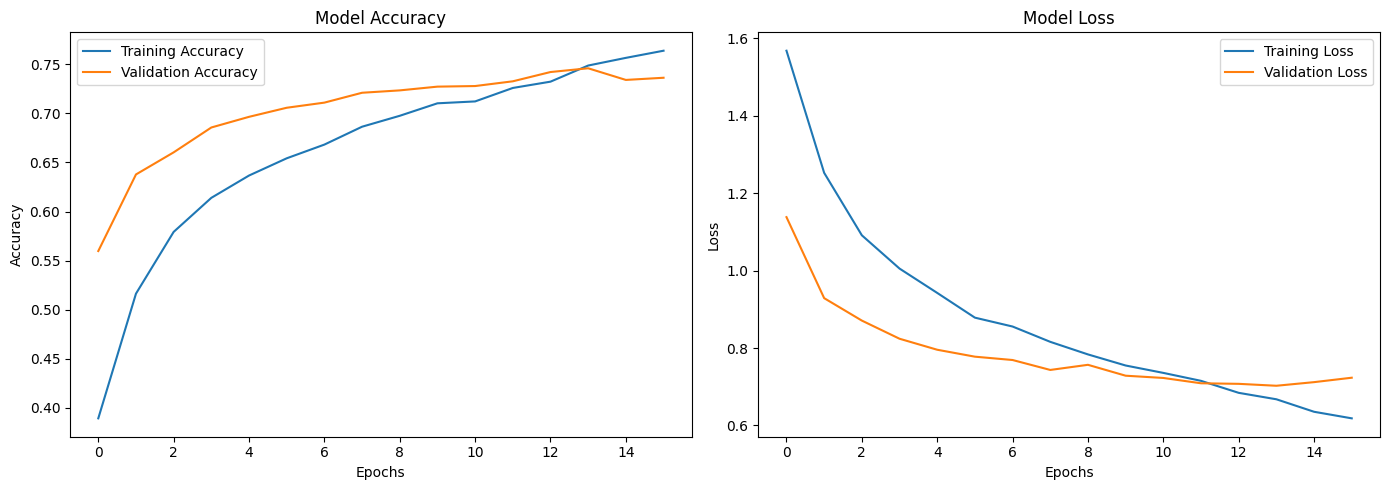

In [138]:
plt.figure(figsize=(14,5))

# --- Accuracy Plot ---
plt.subplot(1,2,1)
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# --- Loss Plot ---
plt.subplot(1,2,2)
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

- Training accuracy improved consistently, indicating that the model learned useful facial features over time.
- Validation accuracy also improved gradually.
- The gap between training accuracy and validation accuracy remains modest, so the model does not show strong overfitting.

The ResNet model shows good learning capacity, but its generalization is still weaker than the tailored CNN architecture.


### **Evaluating the ResNet Model**

In [128]:
model_resnet.load_weights('best_resnet_model.keras')

test_loss, test_acc = model_resnet.evaluate(test_set)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7500 - loss: 0.8278
Test Loss: 0.8277882933616638
Test Accuracy: 0.75


The ResNet transfer learning model was evaluated on the unseen test dataset to measure its final generalization performance:

- Test Loss: `0.828`  
- Test Accuracy: `75%`

This performance is slightly better than CNN Model 1 (`~72%`) and VGG16 (`72.7%`), but still worse than CNN Model 2 (`~83.6%`).



### Confusion Matrix

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
['happy', 'neutral', 'sad', 'surprise']


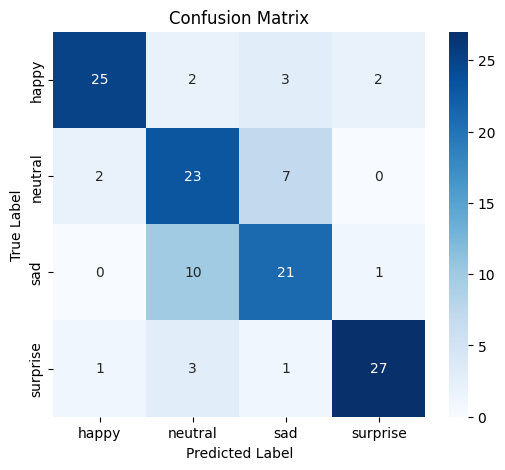

In [129]:
# Generate Predictions
predictions = model_resnet.predict(test_set)

# Convert probabilities to predicted class labels
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = test_set.classes

# Class labels
class_labels = list(test_set.class_indices.keys())
print(class_labels)

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

The same classification pattern persists across all models so far:

- Happy and Surprise are consistently easier to classify.
- Neutral and Sad remain the most difficult pair to distinguish.

Compared with the earlier models, the ResNet architecture did not significantly improve the discrimination between neutral and sad expressions, which remains the dominant source of error.



### Classification report analysis

In [126]:
# Classification report
print(classification_report(true_classes,
                            predicted_classes,
                            target_names=class_labels))

              precision    recall  f1-score   support

       happy       0.89      0.78      0.83        32
     neutral       0.61      0.72      0.66        32
         sad       0.66      0.66      0.66        32
    surprise       0.90      0.84      0.87        32

    accuracy                           0.75       128
   macro avg       0.76      0.75      0.75       128
weighted avg       0.76      0.75      0.75       128



ResNet transfer learning performs reasonably well and improves over the first custom CNN, but it still does not outperform the deeper custom CNN Model 2. This suggests that although pretrained ResNet features are useful, the mismatch between ImageNet-pretrained RGB representations and this low-resolution grayscale facial emotion dataset limits its advantage.



 ------------------------------------------------------------------------

  ------------------------------------------------------------------------

## **EfficientNet Model**

To further evaluate transfer learning approaches for facial emotion recognition, we next use EfficientNet, a family of convolutional neural networks that scales network depth, width, and input resolution in a balanced way, allowing it to extract rich image features while remaining computationally efficient.

EfficientNet is also used as a pretrained feature extractor, followed by a custom classification head for the four emotion classes.

The goal is to assess whether a more efficient transfer learning architecture can improve facial emotion classification performance on this dataset.

In [105]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Data loaders
train_set, validation_set, test_set = build_generators(preprocess_input, batch_size=64)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


In [106]:
#backend.clear_session()

In [107]:
img_size = 128
efficientnet = EfficientNetB0(include_top=False,
                              weights="imagenet",
                              input_shape= (img_size, img_size, 3))

efficientnet.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 128, 128,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

### **Model Building**


The base of the model is a pretrained EfficientNet network, originally trained on the ImageNet dataset. Also in this model, only the deepest layers of EfficientNet are unfrozen while all earlier layers remain frozen.

Thus, the model is able to reuse general visual features learned from large-scale image data while adjusting higher-level features to the target task.


In [108]:
num_classes = 4

for layer in efficientnet.layers:
    if layer.name.startswith("block7a") or \
       layer.name.startswith("top"):
        layer.trainable = True
    else:
        layer.trainable = False


model_effnet = Sequential()

# Pretrained Efficientnet base
model_effnet.add(efficientnet)
model_effnet.add(GlobalAveragePooling2D())
model_effnet.add(Dropout(0.5))

# Classification head
model_effnet.add(Dense(128, kernel_regularizer=l2(1e-4)))
model_effnet.add(BatchNormalization())
model_effnet.add(LeakyReLU(negative_slope=0.1))
model_effnet.add(Dropout(0.5))

# Output layer
model_effnet.add(Dense(num_classes, activation='softmax'))

model_effnet.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,567 (16.08 MB)

 Trainable params: 1,294,132 (4.94 MB)

 Non-trainable params: 2,920,435 (11.14 MB)

### **Compiling and Training the Model**

In [109]:
# --- Callbacks ---

# Early stopping
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    min_delta = 0,
    verbose = 1,
    restore_best_weights = True
    )

# Reduce learning rate
reduce_lr = ReduceLROnPlateau(
    monitor = "val_loss",
    patience = 2,
    factor = 0.5,
    min_lr = 1e-8,
    verbose = 1
    )

# Model checkpoint
checkpoint = ModelCheckpoint(
    filepath = "best_effnet_model.keras",
    monitor = "val_accuracy",
    save_best_only = True,
    mode = 'max',
    verbose = 1
    )

epochs = 30

In [110]:
model_effnet.compile(
    optimizer = Adam(learning_rate = 1e-4),
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics = ["accuracy"]
    )

In [111]:
history_effnet = model_effnet.fit(
    train_set,
    validation_data = validation_set,
    epochs = epochs,
    callbacks = [early_stop, reduce_lr, checkpoint]
    )

Epoch 1/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.3232 - loss: 1.8281
Epoch 1: val_accuracy improved from None to 0.58248, saving model to best_effnet_model.keras

Epoch 1: finished saving model to best_effnet_model.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 146s 478ms/step - accuracy: 0.3811 - loss: 1.6575 - val_accuracy: 0.5825 - val_loss: 1.1215 - learning_rate: 1.0000e-04
Epoch 2/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.4795 - loss: 1.3907
Epoch 2: val_accuracy improved from 0.58248 to 0.63512, saving model to best_effnet_model.keras

Epoch 2: finished saving model to best_effnet_model.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 73s 309ms/step - accuracy: 0.4897 - loss: 1.3565 - val_accuracy: 0.6351 - val_loss: 1.0444 - learning_rate: 1.0000e-04
Epoch 3/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.5318 - loss: 1.2846
Epoch 3: val_accuracy improved from 0.63512 to 0.66446, saving model to best_effnet_model.keras

Epoch 3: finished saving model to b

The EfficientNet model achieved a best validation accuracy of `~76.0%` and shows strong, stable learning throughout training.

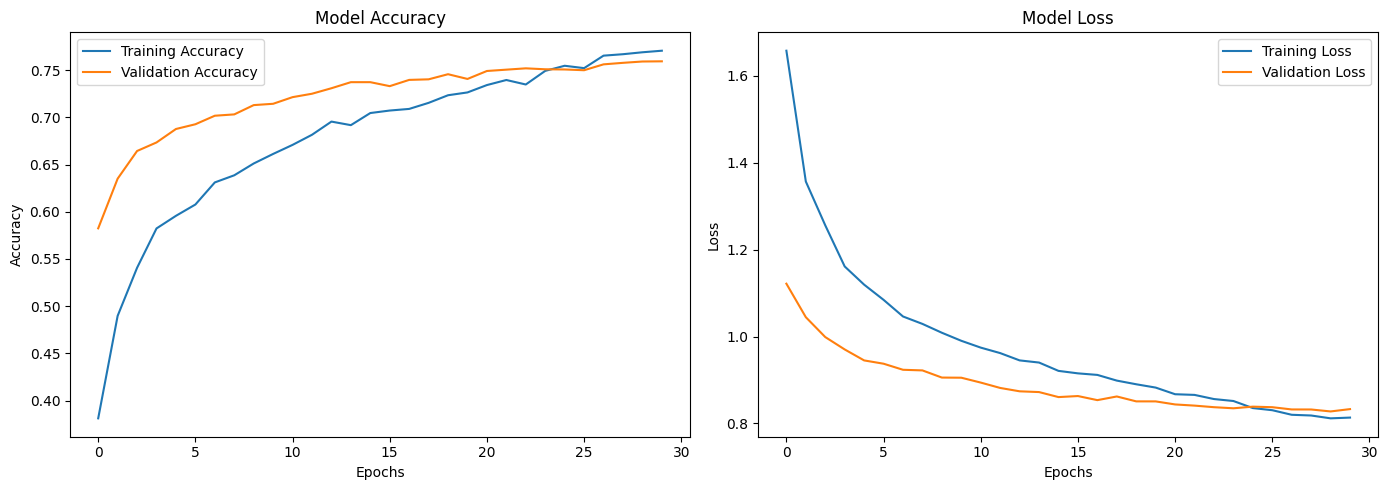

In [112]:
plt.figure(figsize=(14,5))

# --- Accuracy Plot ---
plt.subplot(1,2,1)
plt.plot(history_effnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_effnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# --- Loss Plot ---
plt.subplot(1,2,2)
plt.plot(history_effnet.history['loss'], label='Training Loss')
plt.plot(history_effnet.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

- Training accuracy increased steadily, indicating that the model learned increasingly useful facial representations over time.
- Validation accuracy improved consistently across epochs and reached its best value of approximately `76.0%`, which is:
  - slightly better than ResNet (`73.9%`) and VGG16 (`74.0%`)
  - competitive with CNN Model 2 (`76.4%`)

- Both training and validation loss decreased steadily, suggesting stable optimization and no severe training instability.
- The gap between training and validation accuracy is moderate, indicating reasonable generalization.

### **Evaluating the EfficientnetNet Model**

In [113]:
# Load best saved model
model_effnet = load_model("best_effnet_model.keras")

#Evaluate the best model on the test set
test_loss, test_accuracy = model_effnet.evaluate(test_set, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.7578 - loss: 0.8075
Test Loss: 0.8075300455093384
Test Accuracy: 0.7578125


The EfficientNet-based model achieved the following performance on the test dataset:

- Test Accuracy: `75.8%`
- Test Loss: `0.808`


EfficientNet slightly outperforms ResNet and VGG16, indicating better feature efficiency.

However, it still does not surpass the custom CNN Model 2.


EfficientNet is the strongest transfer learning architecture among the models tested so far, but a carefully designed task-specific CNN still provides the best validation and test performance on this facial emotion recognition dataset.


### Confusion Matrix

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step
['happy', 'neutral', 'sad', 'surprise']


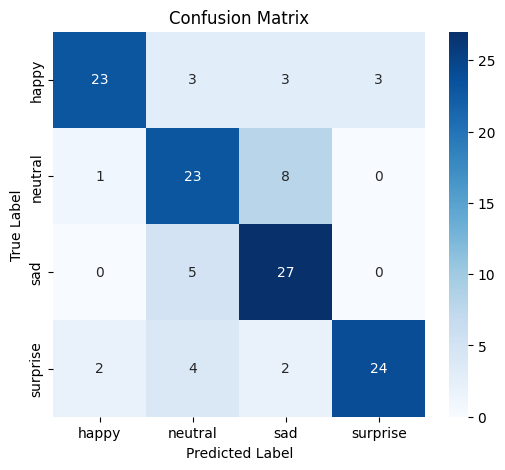

In [114]:
# Generate Predictions
predictions = model_effnet.predict(test_set)

# Convert probabilities to predicted class labels
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = test_set.classes

# Class labels
class_labels = list(test_set.class_indices.keys())
print(class_labels)

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

- The model misses several happy and surprise samples, misclassifying them across other classes.
- Neutral–sad confusion remains a dominant issue, consistent across all models.

Classification report analysis

In [115]:
# Classification report
print(classification_report(true_classes,
                            predicted_classes,
                            target_names=class_labels))

              precision    recall  f1-score   support

       happy       0.88      0.72      0.79        32
     neutral       0.66      0.72      0.69        32
         sad       0.68      0.84      0.75        32
    surprise       0.89      0.75      0.81        32

    accuracy                           0.76       128
   macro avg       0.78      0.76      0.76       128
weighted avg       0.78      0.76      0.76       128



Compared to the custom CNN Model 2:
  - Lower performance across all classes
  - Less consistent discrimination of subtle expressions
  
EfficientNet provides balanced and efficient performance. However, like the other transfer learning models, it is limited by:
- mismatch between pretrained features (ImageNet) and task data (FER)
- difficulty capturing fine-grained emotional differences

Overall, EfficientNet is competitive among transfer learning approaches, but it still does not surpass the task-specific CNN Model 2, which remains the best-performing model due to its alignment with the dataset characteristics and problem structure.

---
---

Now that we have tried multiple pre-trained models, let's build a complex CNN architecture and see if we can get better performance.

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.

The goal is to approach the representational strength of transfer learning architectures while still learning features directly from the facial emotion dataset.

## **Creating our Data Loaders**

In this section, we are creating data loaders which we will use as inputs to the more Complicated Convolutional Neural Network.

In [101]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32
img_size = 48

# Create the test generator
train_datagen_cnn = ImageDataGenerator(rescale=1./255,
                                      horizontal_flip=True,
                                      rotation_range=10,
                                      zoom_range=0.05,
                                      width_shift_range=0.05,
                                      height_shift_range=0.05
                                  )


train_set_cnn = train_datagen_cnn.flow_from_directory(folder_path + "train/",
                                              target_size = (img_size, img_size),
                                              color_mode = "grayscale",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'neutral', 'sad', 'surprise'],
                                              shuffle = True,
                                              seed=SEED
                                              )

# Create the validation generator
validation_datagen_cnn = ImageDataGenerator(rescale=1./255)

validation_set_cnn = validation_datagen_cnn.flow_from_directory(folder_path + "validation/",
                                                        target_size = (img_size, img_size),
                                                        color_mode = "grayscale",
                                                        batch_size = batch_size,
                                                        class_mode = 'categorical',
                                                        classes = ['happy', 'neutral', 'sad', 'surprise'],
                                                        shuffle = False,
                                                        seed=SEED
                                                        )

# Create the test generator
test_datagen_cnn = ImageDataGenerator(rescale=1./255)

test_set_cnn = test_datagen_cnn.flow_from_directory(folder_path + "test/",
                                            target_size = (img_size, img_size),
                                            color_mode = "grayscale",
                                            batch_size = batch_size,
                                            class_mode = 'categorical',
                                            classes = ['happy', 'neutral', 'sad', 'surprise'],
                                            shuffle = False,
                                            seed=SEED
                                            )


Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


In [87]:
print(train_set_cnn.class_indices)

images, labels = next(train_set_cnn)
print(images.shape)
print(labels.shape)

{'happy': 0, 'neutral': 1, 'sad': 2, 'surprise': 3}
(32, 48, 48, 1)
(32, 4)


### **Model Building**

In [102]:
backend.clear_session()

The network uses stacked `3×3` convolutional layers with Batch Normalization and LeakyReLU activations in each block. This design allows the model to learn increasingly complex spatial patterns, from low-level facial edges and contours to higher-level expression-specific structures.

In [103]:
input_shape = (48, 48, 1)
num_classes = 4

model_cnn_deep = Sequential()

# Block 1
model_cnn_deep.add(Conv2D(64, (3, 3), padding='same', input_shape=input_shape))
model_cnn_deep.add(BatchNormalization())
model_cnn_deep.add(LeakyReLU(negative_slope=0.1))

model_cnn_deep.add(Conv2D(64, (3, 3), padding='same'))
model_cnn_deep.add(BatchNormalization())
model_cnn_deep.add(LeakyReLU(negative_slope=0.1))

model_cnn_deep.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn_deep.add(Dropout(0.25))

# Block 2
model_cnn_deep.add(Conv2D(64, (3, 3), padding='same', input_shape=input_shape))
model_cnn_deep.add(BatchNormalization())
model_cnn_deep.add(LeakyReLU(negative_slope=0.1))

model_cnn_deep.add(Conv2D(128, (3, 3), padding='same'))
model_cnn_deep.add(BatchNormalization())
model_cnn_deep.add(LeakyReLU(negative_slope=0.1))

model_cnn_deep.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn_deep.add(Dropout(0.25))

# Block 3
model_cnn_deep.add(Conv2D(128, (3, 3), padding='same'))
model_cnn_deep.add(BatchNormalization())
model_cnn_deep.add(LeakyReLU(negative_slope=0.1))

model_cnn_deep.add(Conv2D(128, (3, 3), padding='same'))
model_cnn_deep.add(BatchNormalization())
model_cnn_deep.add(LeakyReLU(negative_slope=0.1))

model_cnn_deep.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn_deep.add(Dropout(0.30))

# Block 4
model_cnn_deep.add(Conv2D(256, (3, 3), padding='same'))
model_cnn_deep.add(BatchNormalization())
model_cnn_deep.add(LeakyReLU(negative_slope=0.1))

model_cnn_deep.add(Conv2D(256, (3, 3), padding='same'))
model_cnn_deep.add(BatchNormalization())
model_cnn_deep.add(LeakyReLU(negative_slope=0.1))

model_cnn_deep.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn_deep.add(Dropout(0.4))

# Block 5
model_cnn_deep.add(Conv2D(512, (3, 3), padding='same'))
model_cnn_deep.add(BatchNormalization())
model_cnn_deep.add(LeakyReLU(negative_slope=0.1))

model_cnn_deep.add(Conv2D(512, (3, 3), padding='same'))
model_cnn_deep.add(BatchNormalization())
model_cnn_deep.add(LeakyReLU(negative_slope=0.1))

model_cnn_deep.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn_deep.add(Dropout(0.40))

# Classification head
model_cnn_deep.add(GlobalAveragePooling2D())

model_cnn_deep.add(Dense(256, kernel_regularizer=l2(1e-4)))
model_cnn_deep.add(BatchNormalization())
model_cnn_deep.add(LeakyReLU(negative_slope=0.1))
model_cnn_deep.add(Dropout(0.40))

model_cnn_deep.add(Dense(256, kernel_regularizer=l2(1e-4)))
model_cnn_deep.add(BatchNormalization())
model_cnn_deep.add(LeakyReLU(negative_slope=0.1))
model_cnn_deep.add(Dropout(0.40))

# Output layer
model_cnn_deep.add(Dense(num_classes, activation='softmax'))

model_cnn_deep.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 12, 12, 128)    │             

 Total params: 5,077,380 (19.37 MB)

 Trainable params: 5,072,132 (19.35 MB)

 Non-trainable params: 5,248 (20.50 KB)

### **Compiling and Training the Model**

In [104]:
# --- Callbacks ---

# Early stopping
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    min_delta = 0,
    verbose = 1,
    restore_best_weights = True
    )

# Reduce learning rate
reduce_lr = ReduceLROnPlateau(
    monitor = "val_loss",
    patience = 2,
    factor = 0.5,
    min_lr = 1e-6,
    verbose = 1
    )

# Model checkpoint
checkpoint = ModelCheckpoint(
    filepath = "best_model_cnn.keras",
    monitor = "val_accuracy",
    save_best_only = True,
    mode = 'max',
    verbose = 1
    )

epochs = 40

In [91]:
model_cnn_deep.compile(
    optimizer = Adam(learning_rate = 0.0008),
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics = ["accuracy"]
    )

In [92]:
history_cnn = model_cnn_deep.fit(
    train_set_cnn,
    validation_data = validation_set_cnn,
    epochs = epochs,
    callbacks = [early_stop, reduce_lr, checkpoint]
    )

Epoch 1/40


471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2872 - loss: 1.6563
Epoch 1: val_accuracy improved from None to 0.33333, saving model to best_model_cnn.keras

Epoch 1: finished saving model to best_model_cnn.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - accuracy: 0.3144 - loss: 1.5487 - val_accuracy: 0.3333 - val_loss: 1.3577 - learning_rate: 8.0000e-04
Epoch 2/40
471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3952 - loss: 1.3720
Epoch 2: val_accuracy improved from 0.33333 to 0.48523, saving model to best_model_cnn.keras

Epoch 2: finished saving model to best_model_cnn.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.4185 - loss: 1.3381 - val_accuracy: 0.4852 - val_loss: 1.2374 - learning_rate: 8.0000e-04
Epoch 3/40
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5039 - loss: 1.2216
Epoch 3: val_accuracy improved from 0.48523 to 0.56359, saving model to best_model_cnn.keras

Epoch 3: finished saving model to best_model_cnn.keras
473/473 ━━━━

The complex CNN shows strong and stable learning behavior, with the best validation accuracy reaching `78.1%`. This is an improvement over the previous models.


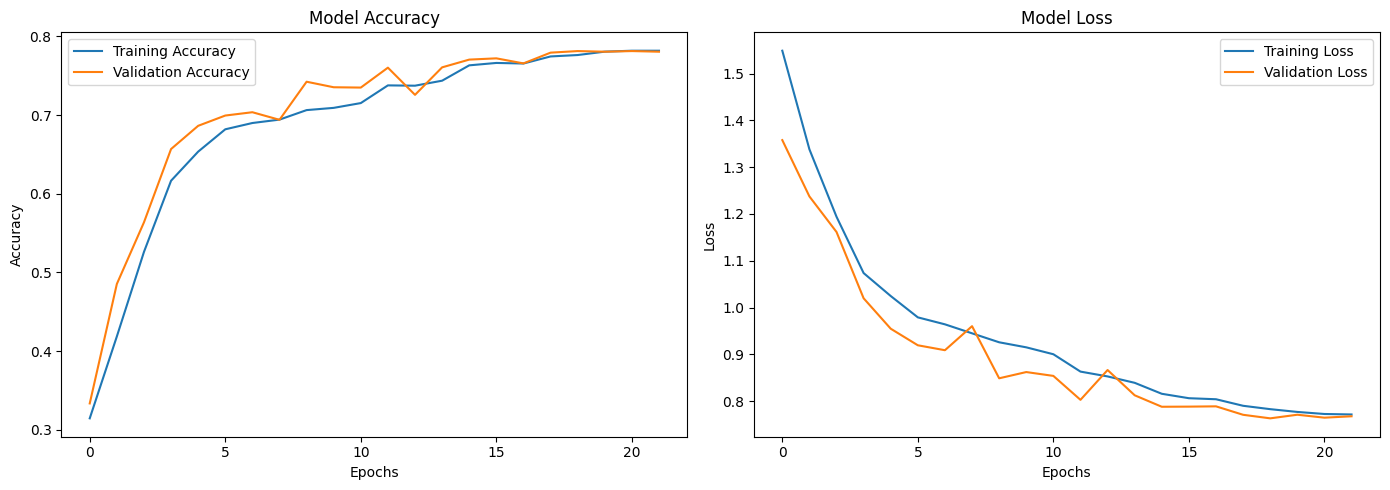

In [93]:
plt.figure(figsize=(14,5))

# --- Accuracy Plot ---
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# --- Loss Plot ---
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

- Training accuracy increased steadily, showing that the model learned increasingly discriminative facial features.
- Validation accuracy improved consistently and remained close to training accuracy throughout training, indicating good generalization.
- Validation loss also decreased steadily before stabilizing.


### **Evaluating the Model on Test Set**

In [95]:
# Load best saved model
model_cnn_deep = load_model("best_model_cnn.keras")

# Reset generator
test_set_cnn.reset()

#Evaluate the best model on the test set
test_loss, test_accuracy = model_cnn_deep.evaluate(test_set_cnn, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8125 - loss: 0.7075
Test Loss: 0.7074916362762451
Test Accuracy: 0.8125


The deep custom CNN was evaluated on the unseen test dataset and achieved strong final performance:

- Test Loss: `0.707`
- Test Accuracy: `81.3%`

The complex CNN outperforms all transfer learning models tested so far.
- It also shows a substantial improvement over CNN Model 1.
- However, it still performs slightly below CNN Model 2, which remains the best-performing model on the test set.


### **Plotting the Confusion Matrix for the chosen final model**

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step 
['happy', 'neutral', 'sad', 'surprise']


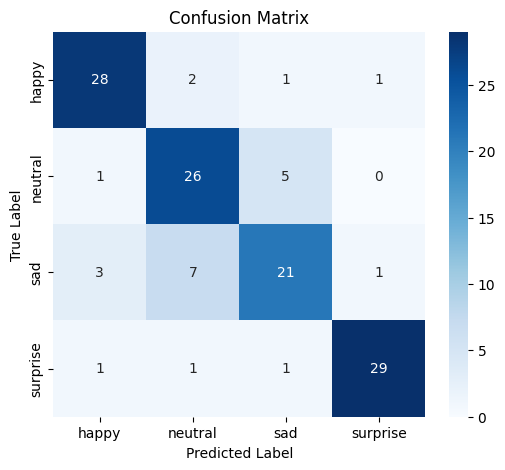

In [96]:
# Generate Predictions
predictions = model_cnn_deep.predict(test_set_cnn)

# Convert probabilities to predicted class labels
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = test_set_cnn.classes

# Class labels
class_labels = list(test_set_cnn.class_indices.keys())
print(class_labels)

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Similar to earlier models, the main classification difficulty remains distinguishing between neutral and sad expression.

### Clasification report analysis

In [97]:
# Classification report
print(classification_report(true_classes,
                            predicted_classes,
                            target_names=class_labels))

              precision    recall  f1-score   support

       happy       0.85      0.88      0.86        32
     neutral       0.72      0.81      0.76        32
         sad       0.75      0.66      0.70        32
    surprise       0.94      0.91      0.92        32

    accuracy                           0.81       128
   macro avg       0.81      0.81      0.81       128
weighted avg       0.81      0.81      0.81       128



The complex CNN is a strong, well-generalized model and clearly outperforms transfer learning approaches. However, CNN Model 2 remains the best overall model.

---
---

## Conclusion

In this project, multiple deep learning architectures were developed and evaluated for facial emotion recognition, including custom CNN models and transfer learning approaches (VGG16, ResNet, and EfficientNet).

Among all models, CNN Model 2 achieved the highest test accuracy (`~83.6%`), followed by the complex CNN (`~81.3%`), while transfer learning models achieved moderate performance in the range of `73–76%`.

These results demonstrate that task-specific CNN architectures outperform pretrained ImageNet models for this problem. The FER dataset consists of low-resolution grayscale facial images, which differ significantly from the natural RGB images used in ImageNet pretraining. As a result, transfer learning models are less effective at capturing the fine-grained emotional features required for accurate classification.

Overall, the project shows that carefully designed, problem-specific architectures combined with proper training strategies can achieve strong performance without relying heavily on transfer learning.

---

### **Model Performance Comparison**

| Model | Test Accuracy | Test Loss | Precision | Recall | F1-Score |
|------|--------------|----------|-----------|--------|----------|
| CNN Model 1 | 71.9% | 0.665 | 0.73 | 0.72 | 0.72 |
| VGG16 | 72.7% | 0.728 | 0.75 | 0.73 | 0.73 |
| ResNet | 75.0% | 0.828 | 0.76 | 0.75 | 0.75 |
| EfficientNet | 75.8% | 0.808 | 0.78 | 0.76 | 0.76 |
| Complex CNN | 81.3% | 0.707 | 0.81 | 0.81 | 0.81 |
| CNN Model 2 | **83.6%** | **0.454** | 0.84 | 0.84 | 0.84 |

The selected metrics provide a comprehensive evaluation of model performance. While accuracy gives an overall measure of correctness, precision and recall capture class-wise performance, and F1-score balances the trade-off between false positives and false negatives, which is important for distinguishing similar emotions.

**CNN Model 2 is the best-performing model**, achieving the highest accuracy and the lowest test loss, indicating both strong predictive performance and confident predictions.

Complex CNN is a close second in accuracy, but its test loss (`0.707`) is significantly higher.  
- This suggests that while it predicts the correct class often, it does so with lower confidence or less stable probability distributions.
- The discrepancy between accuracy and loss in the Complex CNN highlights an important insight:  
  - Two models can have similar accuracy, but very different reliability in their predictions.

Transfer learning models (VGG16, ResNet, EfficientNet) achieve moderate accuracy but consistently higher loss values, indicating less confident and less well-calibrated predictions.



---

### **Key Insights**

#### **Custom CNNs outperform transfer learning models**
- CNN Model 2 and the complex CNN consistently outperformed VGG16, ResNet, and EfficientNet.
- This highlights the importance of domain alignment between data and model architecture.

#### **Expression-specific difficulty varies by emotion intensity**
- Surprise and happy were consistently the easiest classes to classify.
- Neutral and sad showed persistent confusion across all models.
  - This suggests overlapping feature representations and insufficient discriminative signals in these classes.

This indicates that subtle facial expressions are harder to separate than high-intensity emotions.

#### **Transfer learning is not always optimal**
- Despite their depth and capacity, pretrained models underperformed due to:
  - mismatch between ImageNet features and FER data
  - reliance on color and texture features not present in grayscale images

#### **Model complexity improves performance up to an optimal point**
- Increasing model complexity led to improved performance, as seen with CNN Model 2 and the complex CNN.
- However, further complexity did not guarantee better results.
  - The complex CNN achieved competitive accuracy but had higher test loss, indicating less confident predictions.

This suggests that well-balanced architectures outperform overly complex ones.


---

## Recommendations

1. **Proceed with CNN Model 2 as the preferred model**
   - Among all models tested, CNN Model 2 achieved the strongest overall performance on the test set.
   - It provides the best balance between accuracy and generalization and should be considered the leading candidate for further use.

2. **Use the model with caution in applications involving subtle emotions**
   - The analysis shows that the model performs especially well on visually distinctive expressions such as happy and surprise, but still struggles when distinguishing more subtle expressions like neutral and sad.
   - For real-world use, predictions involving subtle emotional states should be interpreted carefully.

3. **Position the model as a decision-support tool rather than a standalone decision-maker**
    - Given the remaining classification ambiguity between certain emotions, the model should support human interpretation rather than replace it.
    - This is especially important in sensitive applications such as mental health or behavioral assessment.

4. **Invest further if the target use case requires higher reliability on subtle emotions**
    - If the organization intends to use this system in more sensitive or precision-critical contexts, additional development will be necessary to improve reliability for subtle expressions.

Overall, the results show that facial emotion recognition is feasible for this four-class problem and that a tailored deep learning solution can achieve strong performance. This supports moving from experimentation toward a more focused proof-of-value or pilot phase.

---

### **Scope to Improve Performance Further**

There is clear scope for further improvement, particularly in distinguishing subtle emotional expressions, which remain the primary source of misclassification across all models.

While the best-performing model (CNN Model 2) achieves strong overall performance, the results suggest that the current performance is not yet saturated and can be improved with additional investment.

#### Where Improvements Are Most Likely

- **Data quality and representation**  
  Performance is currently limited by the subtle nature of certain expressions. Improving data quality or diversity would likely yield the largest gains.

- **Model sensitivity to subtle expressions**  
  All models struggle with low-intensity emotional differences, indicating room for improvement in how features are captured and separated.

#### **Practical Implication**

The current system is already strong enough for practical applications involving broad emotion categories. However, for use cases requiring high reliability in subtle emotional distinctions, further development would be beneficial.

Overall, the project demonstrates a solid and effective baseline, with meaningful headroom for improvement, particularly through better handling of ambiguous and low-intensity facial expressions.

---

### **Applications**

This facial emotion recognition system can be applied in:

- Customer experience analytics (e.g., retail, service interactions)
- Mental health monitoring tools
- Driver fatigue and emotion detection systems
- Human-computer interaction (HCI) for adaptive interfaces
- Education technology to track student engagement

The model’s ability to distinguish between high-intensity emotions (e.g., surprise, happy) and subtle expressions (e.g., neutral, sad) makes it particularly valuable in real-world behavioral analysis systems.

---

### References

Mehrabian, A. (1971). *Silent Messages*. Belmont, CA: Wadsworth Publishing Company.
